# ver2_1 — IMU + Environmental Data Classifier

**단일 모델** (IMU 9축 + 환경 3축 = 12축 동시 수집)  
**데이터**: on_desk / outdoor / walking (3클래스)  
**보드**: Arduino Nano 33 BLE Sense Rev2  

> **Runtime:** Python 3.11 / TensorFlow 2.12 (Colab)  
> **Cell 1 실행 후 세션 재시작 → Cell 2부터 계속 실행**

## Setup
Cell 1 실행 후 세션 재시작 → Cell 2부터 계속 실행

In [ ]:
# Cell 1: 기존 TF 제거 (세션 재시작 필요)
!pip uninstall -y tensorflow keras tf-keras tensorflow-text tensorflow-decision-forests tensorflow-estimator tensorboard numpy jax jaxlib ml-dtypes
!pip install --no-cache-dir numpy==1.23.5 pandas

Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0
Found existing installation: keras 3.8.0
Uninstalling keras-3.8.0:
  Successfully uninstalled keras-3.8.0
Found existing installation: tf_keras 2.18.0
Uninstalling tf_keras-2.18.0:
  Successfully uninstalled tf_keras-2.18.0
Found existing installation: tensorflow-text 2.18.1
Uninstalling tensorflow-text-2.18.1:
  Successfully uninstalled tensorflow-text-2.18.1
Found existing installation: tensorflow_decision_forests 1.11.0
Uninstalling tensorflow_decision_forests-1.11.0:
  Successfully uninstalled tensorflow_decision_forests-1.11.0
Found existing installation: tensorboard 2.18.0
Uninstalling tensorboard-2.18.0:
  Successfully uninstalled tensorboard-2.18.0
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: jax 0.5.2
Uninstalling jax-0.5.2:
  Successfully uninstalled jax-0.5.2
Found

In [ ]:
# Cell 2: 필수 패키지 설치 (세션 재시작 후 실행)
!pip install --no-cache-dir tensorflow==2.12.0 keras==2.12.0 tensorboard==2.12.3 tensorflow-estimator==2.12.0 tensorflow-model-optimization==0.8.0 edgeimpulse cbor scikit-learn matplotlib seaborn requests optuna

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 151.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 136.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 143.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 323.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Imports

In [ ]:
import numpy as np
import pandas as pd
import os, json, io, requests, time
from types import SimpleNamespace

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.legacy import Adam
import tensorflow_model_optimization as tfmot
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
import edgeimpulse as ei

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
print('Done — TF', tf.__version__, '/ Optuna', optuna.__version__)

Done — TF 2.12.0 / Optuna 4.9.0


## Parameters

In [28]:
args = SimpleNamespace(epochs=None, learning_rate=None, ensure_determinism=False, batch_size=None)

API_KEY       = 'ei_70dae6e3ddd8271e4ffb232fa513b869461b786cc70e1396'
PROJECT_ID    = 1025877
TARGET_DEVICE = 'arduino-nano-33-ble'   # Rev2도 동일 MCU(nRF52840) — EI 프로파일링 공용
MODEL_DIR     = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

CLASSES        = ['on_desk', 'outdoor', 'walking']
NUM_CLASSES    = len(CLASSES)
WINDOW_MS      = 2000
STRIDE_MS      = 500
FREQUENCY      = 100
WINDOW_SAMPLES = WINDOW_MS * FREQUENCY // 1000   # 200
N_AXES         = 12
INPUT_SIZE     = WINDOW_SAMPLES * N_AXES          # 2400
AXES_NAMES     = ['accX', 'accY', 'accZ', 'gyrX', 'gyrY', 'gyrZ',
                   'magX', 'magY', 'magZ', 'temperature', 'humidity', 'pressure']

EPOCHS        = args.epochs or 30
LEARNING_RATE = args.learning_rate or 0.0005
BATCH_SIZE    = args.batch_size or 32
OPTUNA_TRIALS = 50

ei.API_KEY = API_KEY
BASE    = 'https://studio.edgeimpulse.com/v1/api'
HEADERS = {'x-api-key': API_KEY}

print(f'INPUT_SIZE = {INPUT_SIZE}  ({WINDOW_SAMPLES} samples x {N_AXES} axes)')
print(f'CLASSES    = {CLASSES}')
print(f'TARGET_DEVICE = {TARGET_DEVICE}')

INPUT_SIZE = 2400  (200 samples x 12 axes)
CLASSES    = ['on_desk', 'outdoor', 'walking']
TARGET_DEVICE = arduino-nano-33-ble


## Helper Functions

In [ ]:
def plot_training_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title)
    for ax, k, t in zip([ax1, ax2], ['accuracy', 'loss'], ['Accuracy', 'Loss']):
        ax.plot(history.history[k],          label='train')
        ax.plot(history.history['val_' + k], label='val')
        ax.set_title(t); ax.set_xlabel('epoch'); ax.legend()
    plt.tight_layout(); plt.show()


def plot_cm(title, cm):
    cm_n = cm.astype(float) / cm.sum(axis=1)[:, None]
    plt.figure(figsize=(5, 4))
    ax = sns.heatmap(pd.DataFrame(cm_n * 100, index=CLASSES, columns=CLASSES),
                     annot=True, fmt='.1f', cmap='Blues', cbar=False)
    ax.set_title(title); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.tight_layout(); plt.show()


def save_tflite(b, path):
    with open(path, 'wb') as f: f.write(b)


def evaluate_keras(model, x_test, y_test_cat, title='Keras'):
    probs  = model.predict(x_test, verbose=0)
    y_true = np.argmax(y_test_cat, axis=1)
    y_pred = np.argmax(probs, axis=1)
    acc    = accuracy_score(y_true, y_pred)
    print(f'  Accuracy: {acc:.4f}')
    plot_cm(title, confusion_matrix(y_true, y_pred))
    return probs, acc


def evaluate_tflite(path_or_bytes, x_test, y_test_cat, title='TFLite'):
    if isinstance(path_or_bytes, (bytes, bytearray)):
        interp = tf.lite.Interpreter(model_content=path_or_bytes)
    else:
        interp = tf.lite.Interpreter(model_path=path_or_bytes)
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]
    in_scale,  in_zp  = inp['quantization']
    out_scale, out_zp = out['quantization']
    probs = []
    for sample in x_test:
        x = np.expand_dims(sample, 0)
        if in_scale != 0:
            x = np.clip(x / in_scale + in_zp, -128, 127).astype(np.int8)
        else:
            x = x.astype(inp['dtype'])
        interp.set_tensor(inp['index'], x)
        interp.invoke()
        o = interp.get_tensor(out['index'])
        p = ((o.astype(np.float32) - out_zp) * out_scale)[0] if out_scale != 0 else o[0].astype(np.float32)
        probs.append(p)
    y_true = np.argmax(y_test_cat, axis=1)
    y_pred = np.argmax(probs, axis=1)
    acc    = accuracy_score(y_true, y_pred)
    print(f'  Accuracy: {acc:.4f}')
    plot_cm(title, confusion_matrix(y_true, y_pred))
    return np.array(probs), acc


def convert_fp32_tflite(model_or_path):
    m = keras.models.load_model(model_or_path) if isinstance(model_or_path, str) else model_or_path
    c = tf.lite.TFLiteConverter.from_keras_model(m)
    return c.convert()


def convert_full_int8(model_or_path, rep_fn):
    m = keras.models.load_model(model_or_path) if isinstance(model_or_path, str) else model_or_path
    c = tf.lite.TFLiteConverter.from_keras_model(m)
    c.optimizations = [tf.lite.Optimize.DEFAULT]
    c.representative_dataset = rep_fn
    c.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    c.inference_input_type  = tf.int8
    c.inference_output_type = tf.int8
    return c.convert()


def extract_profile(p):
    if p is None: return None
    try:
        d   = p.to_dict()['model']['profileInfo']
        pv  = [v for k, v in d.items() if k != 'table'][0]
        mem = pv['memory']['tflite']
        return {'RAM_KB': mem['ram'] / 1024,
                'ROM_KB': mem['rom'] / 1024,
                'Latency_ms': pv['timePerInferenceMs']}
    except Exception as e:
        print(f'  extract_profile error: {e}'); return None


def profile_tflite(tflite_bytes, label):
    p = ei.model.profile(model=tflite_bytes, device=TARGET_DEVICE)
    s = extract_profile(p)
    if s:
        ram = s['RAM_KB']; rom = s['ROM_KB']; lat = s['Latency_ms']
        print(f'  {label:<24}  RAM:{ram:6.1f}KB  ROM:{rom:7.1f}KB  Lat:{lat:6.1f}ms')
    return s


def tflite_to_c_header(tflite_path, header_path, array_name):
    with open(tflite_path, 'rb') as fi, open(header_path, 'w') as fo:
        fo.write('#pragma once\n')
        fo.write('alignas(8) const unsigned char ' + array_name + '[] = {\n')
        data = fi.read()
        for i, b in enumerate(data):
            if i % 12 == 0: fo.write('  ')
            fo.write('0x%02x, ' % b)
            if (i + 1) % 12 == 0: fo.write('\n')
        fo.write('\n};\n')
    print(f'Saved {header_path} ({os.path.getsize(header_path)/1024:.1f} KB)')


def arr_to_c(arr, name):
    rows = []
    for i in range(0, len(arr), 8):
        rows.append('    ' + ', '.join('%.8ff' % v for v in arr[i:i+8]) + ',')
    return 'const float ' + name + '[' + str(len(arr)) + '] = {\n' + '\n'.join(rows) + '\n};\n'


print('Helpers defined.')

Helpers defined.


## EI 데이터 다운로드

**접근 방식**: EI impulse에서 Raw Data DSP 블록 ID를 자동 조회한 뒤,  
`/dsp-data/{blockId}/x/{split}` 엔드포인트로 numpy 배열을 다운로드한다.  

Raw Data 블록은 `scale=1`인 항등 변환이므로 출력값 = 원본 센서값 (flattened).  
wavelet/MFE 등 실질적인 feature extraction이 없으므로 원본 데이터와 동일하다.

In [ ]:
CACHE_TRAIN     = 'cache_train.npz'
CACHE_TEST      = 'cache_test.npz'
DSP_ID_OVERRIDE = None  # int: auto-detection 실패 시 블록 ID를 직접 입력 (예: 5)


# ── EI 다운로드 헬퍼 ──────────────────────────────────────────────────────────
def ei_fetch_npy(dsp_id, split):
    r = requests.get(
        f'{BASE}/{PROJECT_ID}/dsp-data/{dsp_id}/x/{split}',
        headers=HEADERS
    )
    r.raise_for_status()
    return np.load(io.BytesIO(r.content))


def ei_fetch_labels(dsp_id, split):
    r = requests.get(
        f'{BASE}/{PROJECT_ID}/dsp-data/{dsp_id}/y/{split}',
        headers=HEADERS
    )
    r.raise_for_status()
    return np.load(io.BytesIO(r.content))[:, 0]


def find_raw_dsp_id():
    """EI impulse에서 Raw Data DSP 블록 ID를 자동 조회한다."""
    if DSP_ID_OVERRIDE is not None:
        print(f'Using DSP_ID_OVERRIDE = {DSP_ID_OVERRIDE}')
        return DSP_ID_OVERRIDE
    r = requests.get(f'{BASE}/{PROJECT_ID}/impulse', headers=HEADERS)
    r.raise_for_status()
    body    = r.json()
    impulse = body.get('impulse', body)
    blocks  = impulse.get('dspBlocks', [])
    for block in blocks:
        if block.get('type', '').lower() in ('raw', 'raw-data', 'rawdata'):
            return block['id']
    # Auto-detection 실패: 전체 블록 목록 출력
    print('Auto-detection 실패. 사용 가능한 DSP 블록:')
    for b in blocks:
        print(f"  id={b.get('id')}  type={b.get('type')!r}  name={b.get('name')!r}")
    print("-> DSP_ID_OVERRIDE 변수를 올바른 id 값으로 설정한 뒤 이 셀을 다시 실행하세요.")
    raise ValueError('Raw Data DSP block not found in EI impulse.')


def cache_valid(path):
    """캐시 파일이 올바른 2D numpy 배열인지 검사한다."""
    if not os.path.exists(path):
        return False
    try:
        d = np.load(path)
        return (d['x'].ndim == 2
                and d['x'].shape[1] == INPUT_SIZE
                and len(d['x']) > 0)
    except Exception:
        return False


# ── Step 0: 잘못된 캐시 무조건 삭제 (세션 재사용 시 stale 캐시 방지) ──────────
for _cache_path in [CACHE_TRAIN, CACHE_TEST]:
    if os.path.exists(_cache_path) and not cache_valid(_cache_path):
        os.remove(_cache_path)
        print(f'Removed stale/corrupt cache: {_cache_path}')

# ── EI 레이블 매핑: 알파벳 오름차순 1-indexed → on_desk=1, outdoor=2, walking=3
EI_CLASSES = sorted(CLASSES)
EI_TO_NB   = {i+1: CLASSES.index(c) for i, c in enumerate(EI_CLASSES)}
print(f'EI class order (alphabetical): {EI_CLASSES}')
print(f'Label map EI->notebook: {EI_TO_NB}')

# ── Step 1: 유효한 캐시 로드 OR EI에서 재다운로드 ─────────────────────────────
if cache_valid(CACHE_TRAIN) and cache_valid(CACHE_TEST):
    print('Loading from valid cache...')
    train_npz  = np.load(CACHE_TRAIN)
    test_npz   = np.load(CACHE_TEST)
    x_train, y_train = train_npz['x'], train_npz['y']
    x_test,  y_test  = test_npz['x'],  test_npz['y']
else:
    DSP_ID = find_raw_dsp_id()
    print(f'Raw Data DSP block id = {DSP_ID}  (scale=1, identity transform)')

    x_train = ei_fetch_npy(DSP_ID, 'training')
    x_test  = ei_fetch_npy(DSP_ID, 'testing')
    y_tr_ei = ei_fetch_labels(DSP_ID, 'training')
    y_te_ei = ei_fetch_labels(DSP_ID, 'testing')

    y_train = np.array([EI_TO_NB[int(v)] for v in y_tr_ei], dtype=np.int32)
    y_test  = np.array([EI_TO_NB[int(v)] for v in y_te_ei], dtype=np.int32)

    np.savez_compressed(CACHE_TRAIN, x=x_train, y=y_train)
    np.savez_compressed(CACHE_TEST,  x=x_test,  y=y_test)
    print('Cached to disk.')

# ── Step 2: shape / label 검증 ────────────────────────────────────────────────
print(f'\nTrain: {x_train.shape}  Test: {x_test.shape}')
assert x_train.ndim == 2 and x_train.shape[1] == INPUT_SIZE, \
    f'Train shape mismatch: {x_train.shape} != (N, {INPUT_SIZE})'
assert x_test.ndim == 2 and x_test.shape[1] == INPUT_SIZE, \
    f'Test shape mismatch: {x_test.shape} != (N, {INPUT_SIZE})'
print('Train label dist:', {CLASSES[i]: int((y_train==i).sum()) for i in range(NUM_CLASSES)})
print('Test  label dist:', {CLASSES[i]: int((y_test ==i).sum()) for i in range(NUM_CLASSES)})

Removed stale/corrupt cache: cache_train.npz
Removed stale/corrupt cache: cache_test.npz
EI class order (alphabetical): ['on_desk', 'outdoor', 'walking']
Label map EI->notebook: {1: 0, 2: 1, 3: 2}
Raw Data DSP block id = 34  (scale=1, identity transform)
Cached to disk.

Train: (816, 2400)  Test: (204, 2400)
Train label dist: {'on_desk': 272, 'outdoor': 272, 'walking': 272}
Test  label dist: {'on_desk': 68, 'outdoor': 68, 'walking': 68}


## StandardScaler 정규화 + Train/Val/Test Split

- `StandardScaler`: train set에만 `fit`, test set은 `transform`만
- val split: train의 20%를 validation으로 분리 (stratify 적용)

In [ ]:
y_train_cat = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

scaler       = StandardScaler()
x_train_norm = scaler.fit_transform(x_train)
x_test_norm  = scaler.transform(x_test)

print(f'정규화 후 — mean={x_train_norm.mean():.4f}  std={x_train_norm.std():.4f}')
print(f'scaler.mean_[:3]  = {scaler.mean_[:3]}')
print(f'scaler.scale_[:3] = {scaler.scale_[:3]}')

x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_norm, y_train_cat,
    test_size=0.2, random_state=42, stratify=y_train)

print(f'\nTrain: {x_tr.shape}  Val: {x_val.shape}  Test: {x_test_norm.shape}')

정규화 후 — mean=-0.0000  std=0.8660
scaler.mean_[:3]  = [-1.4414956e-09 -7.7073791e-09  8.8749563e-09]
scaler.scale_[:3] = [1.         1.00000001 1.00000001]

Train: (652, 2400)  Val: (164, 2400)  Test: (204, 2400)


## NN 모델 빌더 (EI Classifier 아키텍처)

Dense(d1, relu, L1) → Dropout → Dense(d2, relu, L1) → Dense(3, softmax)

In [ ]:
def build_model(d1=20, d2=10, dropout=0.2, lr=0.0005):
    model = Sequential([
        keras.layers.Input(shape=(INPUT_SIZE,)),
        Dense(d1, activation='relu',
              activity_regularizer=tf.keras.regularizers.l1(0.00001)),
        Dropout(dropout),
        Dense(d2, activation='relu',
              activity_regularizer=tf.keras.regularizers.l1(0.00001)),
        Dense(NUM_CLASSES, name='y_pred', activation='softmax')
    ], name='classifier')
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

build_model().summary()

Model: "classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 20)                48020     
                                                                 
 dropout (Dropout)           (None, 20)                0         
                                                                 
 dense_1 (Dense)             (None, 10)                210       
                                                                 
 y_pred (Dense)              (None, 3)                 33        
                                                                 
Total params: 48,263
Trainable params: 48,263
Non-trainable params: 0
_________________________________________________________________


## Optuna 다목적 최적화

- Objective 1: test accuracy **maximize**
- Objective 2: PTQ INT8 model size (KB) **minimize**
- Search space: d1 ∈ {16,32,64}, d2 ∈ {8,16,32}, dropout, lr, batch

In [ ]:
def objective(trial):
    d1      = trial.suggest_categorical('d1',    [16, 32, 64])
    d2      = trial.suggest_categorical('d2',    [8, 16, 32])
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr      = trial.suggest_float('lr',      1e-4, 1e-2, log=True)
    batch   = trial.suggest_categorical('batch', [16, 32, 64])

    m = build_model(d1, d2, dropout, lr)
    m.fit(x_tr, y_tr,
          batch_size=batch, epochs=30,
          validation_data=(x_val, y_val),
          callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
          verbose=0)

    acc = m.evaluate(x_test_norm, y_test_cat, verbose=0)[1]

    def rep_fn():
        idx = np.random.choice(len(x_train_norm), 50, replace=False)
        for i in idx:
            yield [np.expand_dims(x_train_norm[i], 0).astype(np.float32)]

    ptq_bytes = convert_full_int8(m, rep_fn)
    size_kb   = len(ptq_bytes) / 1024
    return acc, size_kb


study = optuna.create_study(
    study_name='clf_multi_obj',
    directions=['maximize', 'minimize']
)
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
print(f'완료 — Pareto front: {len(study.best_trials)} trials')

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:789: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "
/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:789: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "
/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:789: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "
/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:789: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but no

완료 — Pareto front: 3 trials


/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:789: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


## Pareto Front 확인 및 Best Trial 선택

Accuracy 최우선, 동점이면 INT8 size 작은 것 선택

 Trial   Accuracy   Size(KB)  Params
    40     1.0000      40.38  {'d1': 16, 'd2': 16, 'dropout': 0.2870217351260616, 'lr': 0.0030400076071896666, 'batch': 16}
    43     1.0000      40.38  {'d1': 16, 'd2': 16, 'dropout': 0.1887665628327722, 'lr': 0.009184951597021776, 'batch': 16}
     3     0.9167      40.19  {'d1': 16, 'd2': 8, 'dropout': 0.3022718412125466, 'lr': 0.0034378435392634866, 'batch': 16}

Selected: Trial 40
  Accuracy = 1.0000,  Size = 40.4 KB
  Params   = {'d1': 16, 'd2': 16, 'dropout': 0.2870217351260616, 'lr': 0.0030400076071896666, 'batch': 16}


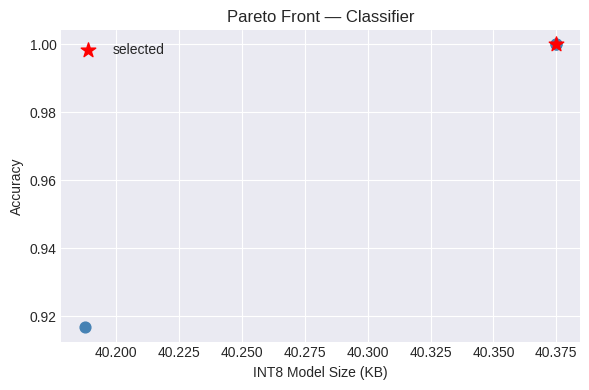

In [ ]:
pareto = study.best_trials
print(f'{"Trial":>6}  {"Accuracy":>9}  {"Size(KB)":>9}  Params')
for t in sorted(pareto, key=lambda t: -t.values[0]):
    print(f'{t.number:>6}  {t.values[0]:>9.4f}  {t.values[1]:>9.2f}  {t.params}')

best = sorted(pareto, key=lambda t: (-t.values[0], t.values[1]))[0]
print(f'\nSelected: Trial {best.number}')
print(f'  Accuracy = {best.values[0]:.4f},  Size = {best.values[1]:.1f} KB')
print(f'  Params   = {best.params}')

accs  = [t.values[0] for t in pareto]
sizes = [t.values[1] for t in pareto]
plt.figure(figsize=(6, 4))
plt.scatter(sizes, accs, c='steelblue', s=60)
plt.scatter(best.values[1], best.values[0], c='red', s=120, marker='*', label='selected')
plt.xlabel('INT8 Model Size (KB)'); plt.ylabel('Accuracy')
plt.title('Pareto Front — Classifier'); plt.legend(); plt.tight_layout(); plt.show()

## 최종 모델 학습 (Best Hyperparams)

Epoch 1/100
41/41 [==============================] - 1s 9ms/step - loss: 0.1232 - accuracy: 0.9571 - val_loss: 0.0053 - val_accuracy: 1.0000
Epoch 2/100
41/41 [==============================] - 0s 4ms/step - loss: 0.0232 - accuracy: 0.9939 - val_loss: 0.0029 - val_accuracy: 1.0000
Epoch 3/100
41/41 [==============================] - 0s 4ms/step - loss: 0.0197 - accuracy: 0.9939 - val_loss: 0.0023 - val_accuracy: 1.0000
Epoch 4/100
41/41 [==============================] - 0s 4ms/step - loss: 0.0093 - accuracy: 0.9954 - val_loss: 0.0020 - val_accuracy: 1.0000
Epoch 5/100
41/41 [==============================] - 0s 4ms/step - loss: 0.0042 - accuracy: 1.0000 - val_loss: 0.0021 - val_accuracy: 1.0000
Epoch 6/100
41/41 [==============================] - 0s 4ms/step - loss: 0.0076 - accuracy: 0.9985 - val_loss: 0.0021 - val_accuracy: 1.0000
Epoch 7/100
41/41 [==============================] - 0s 4ms/step - loss: 0.0081 - accuracy: 0.9985 - val_loss: 0.0022 - val_accuracy: 1.0000
Epoch 8/100
4

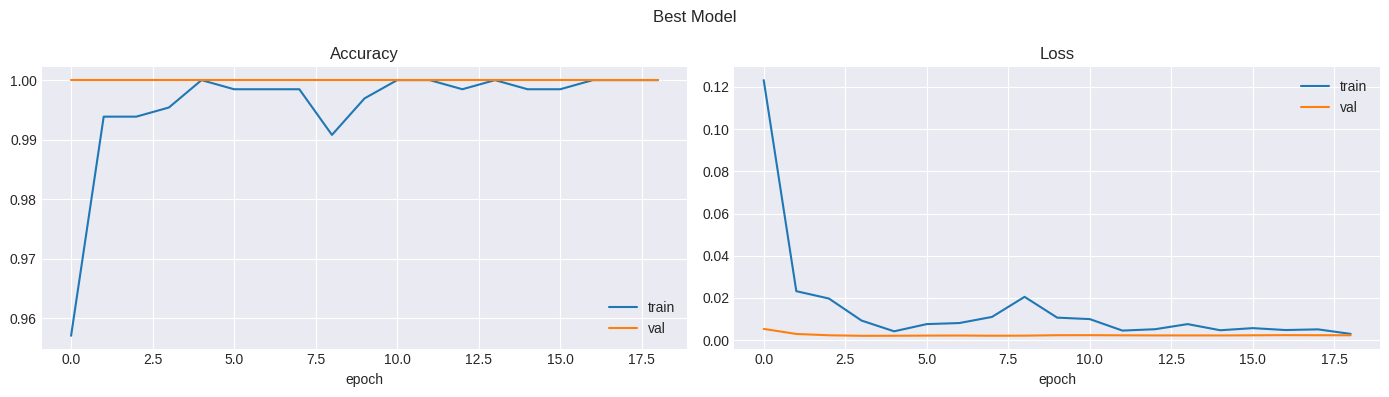

In [ ]:
bp = best.params
final_model = build_model(d1=bp['d1'], d2=bp['d2'], dropout=bp['dropout'], lr=bp['lr'])
history = final_model.fit(
    x_tr, y_tr,
    batch_size=bp['batch'], epochs=100,
    validation_data=(x_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
    verbose=1
)
plot_training_history(history, 'Best Model')
final_model.save(f'{MODEL_DIR}/model.keras')

---
## 4가지 포맷 평가

각 포맷마다: **Accuracy** + **Confusion Matrix** + **EI 하드웨어 프로파일링**

| # | 포맷 | 변환 |
|---|------|------|
| 1 | Keras original | param_size, Colab CPU latency |
| 2 | FP32 TFLite | 기본 TFLiteConverter |
| 3 | PTQ INT8 | optimizations=DEFAULT + representative dataset |
| 4 | QAT INT8 | tfmot.quantize_model fine-tune 후 변환 |

=== 1. Keras Original ===
  Accuracy: 0.9167


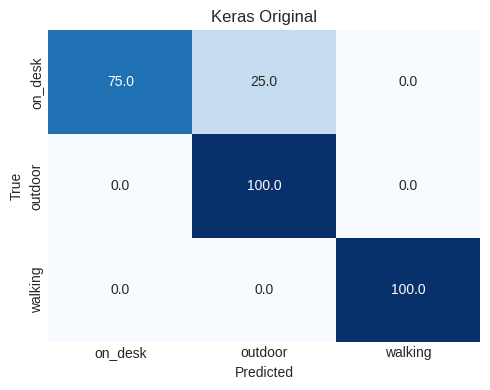

  Param size : 151.3 KB  (float32)
  CPU latency: 72.762 ms  (Colab CPU)
  HW RAM/ROM/Latency: N/A


In [ ]:
# 1. Keras Original
print('=== 1. Keras Original ===')
keras_probs, keras_acc = evaluate_keras(
    final_model, x_test_norm, y_test_cat, title='Keras Original')

keras_param_kb = final_model.count_params() * 4 / 1024
t0 = time.perf_counter()
for _ in range(100):
    final_model.predict(x_test_norm[:1], verbose=0)
keras_cpu_ms = (time.perf_counter() - t0) / 100 * 1000

print(f'  Param size : {keras_param_kb:.1f} KB  (float32)')
print(f'  CPU latency: {keras_cpu_ms:.3f} ms  (Colab CPU)')
print('  HW RAM/ROM/Latency: N/A')

=== 2. FP32 TFLite ===
  File size: 153.4 KB
  Accuracy: 0.9167


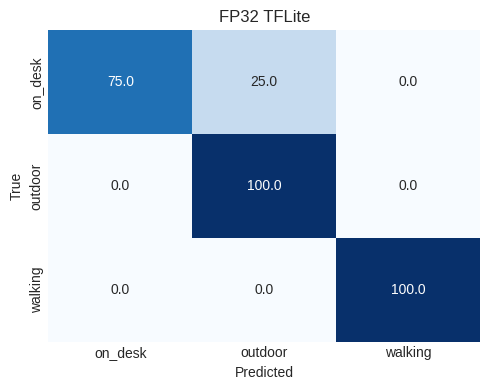

  FP32 TFLite               RAM:  14.2KB  ROM:  184.9KB  Lat:   5.0ms


In [29]:
# 2. FP32 TFLite
print('=== 2. FP32 TFLite ===')
fp32_bytes   = convert_fp32_tflite(f'{MODEL_DIR}/model.keras')
save_tflite(fp32_bytes, f'{MODEL_DIR}/model_fp32.tflite')
fp32_size_kb = len(fp32_bytes) / 1024
print(f'  File size: {fp32_size_kb:.1f} KB')

fp32_probs, fp32_acc = evaluate_tflite(
    f'{MODEL_DIR}/model_fp32.tflite', x_test_norm, y_test_cat, title='FP32 TFLite')
fp32_stats = profile_tflite(fp32_bytes, 'FP32 TFLite')

=== 3. PTQ INT8 ===


/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:789: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


  File size: 40.4 KB
  Accuracy: 0.9167


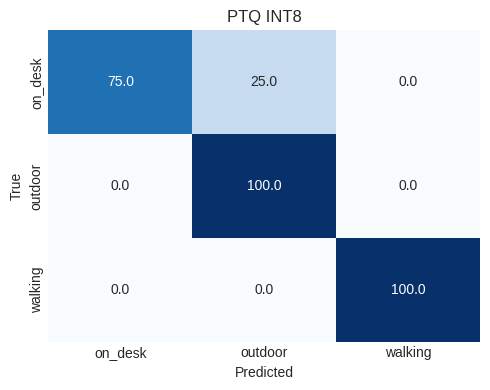

  PTQ INT8                  RAM:   5.8KB  ROM:   71.9KB  Lat:   2.0ms


In [30]:
# 3. PTQ INT8
print('=== 3. PTQ INT8 ===')

def rep_data():
    idx = np.random.choice(len(x_train_norm), min(100, len(x_train_norm)), replace=False)
    for i in idx:
        yield [np.expand_dims(x_train_norm[i], 0).astype(np.float32)]

ptq_bytes   = convert_full_int8(f'{MODEL_DIR}/model.keras', rep_data)
save_tflite(ptq_bytes, f'{MODEL_DIR}/model_ptq.tflite')
ptq_size_kb = len(ptq_bytes) / 1024
print(f'  File size: {ptq_size_kb:.1f} KB')

ptq_probs, ptq_acc = evaluate_tflite(
    f'{MODEL_DIR}/model_ptq.tflite', x_test_norm, y_test_cat, title='PTQ INT8')
ptq_stats = profile_tflite(ptq_bytes, 'PTQ INT8')

=== 4. QAT INT8 ===
Model: "classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLay  (None, 2400)             3         
 er)                                                             
                                                                 
 quant_dense_104 (QuantizeWr  (None, 16)               38421     
 apperV2)                                                        
                                                                 
 quant_dropout_52 (QuantizeW  (None, 16)               1         
 rapperV2)                                                       
                                                                 
 quant_dense_105 (QuantizeWr  (None, 16)               277       
 apperV2)                                                        
                                                                 
 quant_y_pred (QuantizeWrapp  (None,

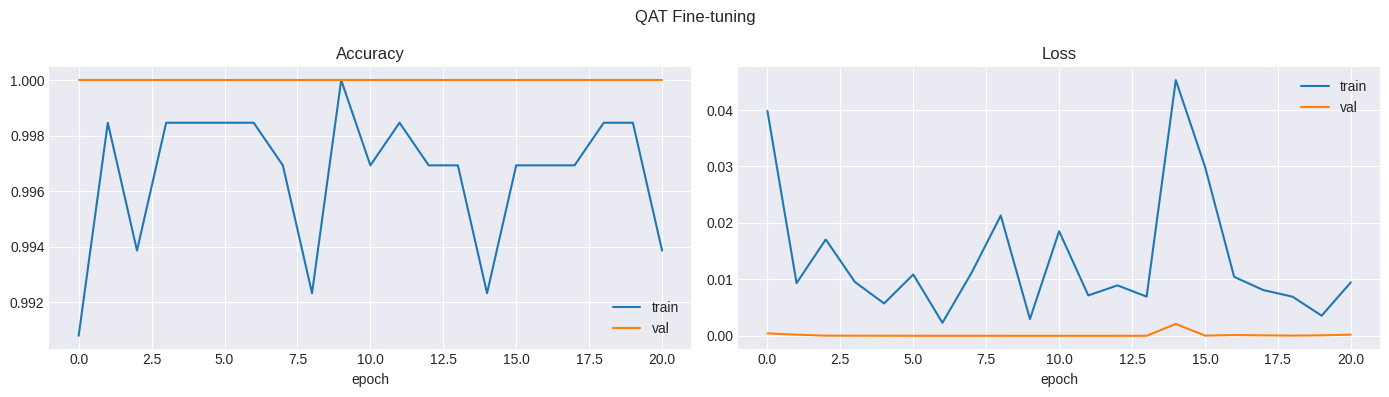

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:789: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


  File size: 40.7 KB
  Accuracy: 0.9167


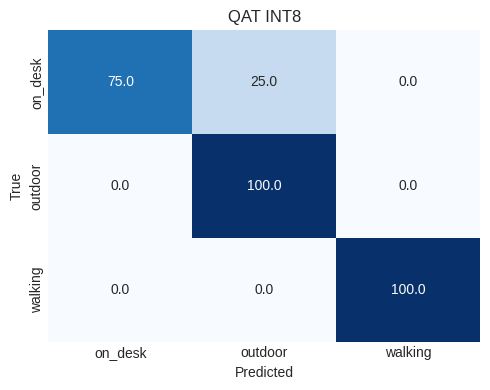

  QAT INT8                  RAM:   5.8KB  ROM:   72.2KB  Lat:   1.0ms


In [31]:
# 4. QAT INT8
print('=== 4. QAT INT8 ===')

def build_model_for_qat(d1, d2, dropout, lr):
    # L1 regularizer 제거 — tfmot.quantize_model 호환성
    model = Sequential([
        keras.layers.Input(shape=(INPUT_SIZE,)),
        Dense(d1, activation='relu'),
        Dropout(dropout),
        Dense(d2, activation='relu'),
        Dense(NUM_CLASSES, name='y_pred', activation='softmax')
    ], name='classifier')
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

trained = keras.models.load_model(f'{MODEL_DIR}/model.keras')
for_qat  = build_model_for_qat(bp['d1'], bp['d2'], bp['dropout'], bp['lr'])
for_qat.set_weights(trained.get_weights())

qat_model = tfmot.quantization.keras.quantize_model(for_qat)
qat_model.compile(optimizer=Adam(learning_rate=bp['lr']),
                  loss='categorical_crossentropy', metrics=['accuracy'])
qat_model.summary()

history_qat = qat_model.fit(
    x_tr, y_tr,
    batch_size=bp['batch'], epochs=30,
    validation_data=(x_val, y_val),
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)
plot_training_history(history_qat, 'QAT Fine-tuning')
qat_model.save(f'{MODEL_DIR}/model_qat.keras')

qat_bytes   = convert_full_int8(qat_model, rep_data)
save_tflite(qat_bytes, f'{MODEL_DIR}/model_qat.tflite')
qat_size_kb = len(qat_bytes) / 1024
print(f'  File size: {qat_size_kb:.1f} KB')

qat_probs, qat_acc = evaluate_tflite(
    f'{MODEL_DIR}/model_qat.tflite', x_test_norm, y_test_cat, title='QAT INT8')
qat_stats = profile_tflite(qat_bytes, 'QAT INT8')

---
## 최종 비교표 (Plot)

  Model                Size(KB)   RAM(KB)    ROM(KB)    Lat(ms)     Acc
-----------------------------------------------------------------------
  Keras original          151.3       N/A        N/A        N/A  0.9167
  FP32 TFLite             153.4      14.2      184.9        5.0  0.9167
  PTQ INT8                 40.4       5.8       71.9        2.0  0.9167
  QAT INT8                 40.7       5.8       72.2        1.0  0.9167
  (Arduino Nano 33 BLE Sense Rev2: 256KB RAM, 1MB Flash)

FP32 -> QAT INT8 reduction:
  Size : 73.5%
  RAM  : 59.1%
  ROM  : 61.0%
  Lat  : 80.0%


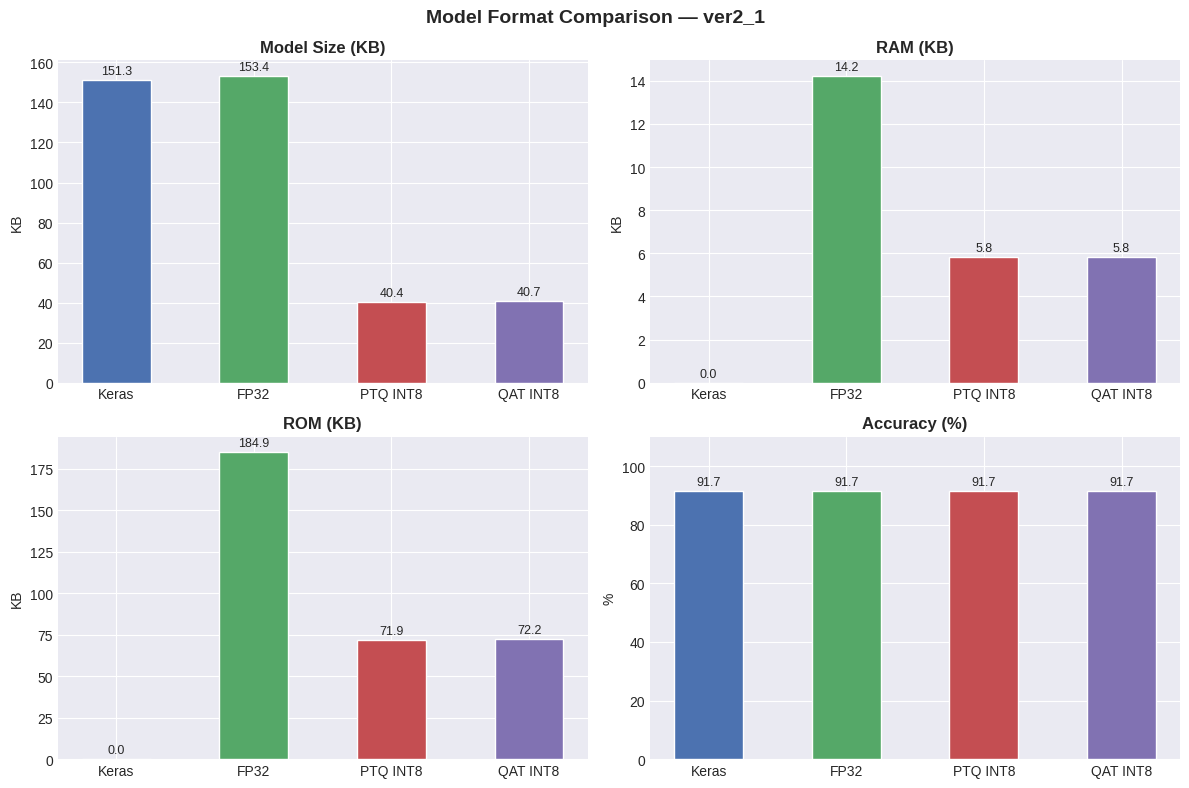

Saved models/comparison.png


In [32]:
def _v(s, k): return s[k] if s else None
def _f(v, w=9): return f'{v:>{w}.1f}' if v is not None else 'N/A'.rjust(w)

rows = [
    ('Keras original', keras_param_kb,
     None, None, None, keras_acc),
    ('FP32 TFLite',    fp32_size_kb,
     _v(fp32_stats,'RAM_KB'), _v(fp32_stats,'ROM_KB'), _v(fp32_stats,'Latency_ms'), fp32_acc),
    ('PTQ INT8',       ptq_size_kb,
     _v(ptq_stats,'RAM_KB'),  _v(ptq_stats,'ROM_KB'),  _v(ptq_stats,'Latency_ms'),  ptq_acc),
    ('QAT INT8',       qat_size_kb,
     _v(qat_stats,'RAM_KB'),  _v(qat_stats,'ROM_KB'),  _v(qat_stats,'Latency_ms'),  qat_acc),
]

HDR = f'  {"Model":<18}  {"Size(KB)":>9}  {"RAM(KB)":>8}  {"ROM(KB)":>9}  {"Lat(ms)":>9}  {"Acc":>6}'
SEP = '=' * len(HDR)
print(SEP); print(HDR); print('-' * len(HDR))
for name, sz, ram, rom, lat, acc in rows:
    print(f'  {name:<18}  {_f(sz)}  {_f(ram,8)}  {_f(rom)}  {_f(lat)}  {acc:.4f}')
print(SEP)
print('  (Arduino Nano 33 BLE Sense Rev2: 256KB RAM, 1MB Flash)')

if fp32_stats and qat_stats:
    fp_sz = fp32_size_kb;  qt_sz  = qat_size_kb
    fp_ram = fp32_stats['RAM_KB']; qt_ram = qat_stats['RAM_KB']
    fp_rom = fp32_stats['ROM_KB']; qt_rom = qat_stats['ROM_KB']
    fp_lat = fp32_stats['Latency_ms']; qt_lat = qat_stats['Latency_ms']
    print(f'\nFP32 -> QAT INT8 reduction:')
    print(f'  Size : {(1-qt_sz/fp_sz)*100:.1f}%')
    print(f'  RAM  : {(1-qt_ram/fp_ram)*100:.1f}%')
    print(f'  ROM  : {(1-qt_rom/fp_rom)*100:.1f}%')
    print(f'  Lat  : {(1-qt_lat/fp_lat)*100:.1f}%')

# ── Bar chart (4 subplots) ────────────────────────────────────────────────────
labels = ['Keras', 'FP32', 'PTQ INT8', 'QAT INT8']
sizes  = [keras_param_kb, fp32_size_kb, ptq_size_kb, qat_size_kb]
rams   = [0, _v(fp32_stats,'RAM_KB') or 0, _v(ptq_stats,'RAM_KB') or 0, _v(qat_stats,'RAM_KB') or 0]
roms   = [0, _v(fp32_stats,'ROM_KB') or 0, _v(ptq_stats,'ROM_KB') or 0, _v(qat_stats,'ROM_KB') or 0]
lats   = [0, _v(fp32_stats,'Latency_ms') or 0, _v(ptq_stats,'Latency_ms') or 0, _v(qat_stats,'Latency_ms') or 0]
accs   = [keras_acc*100, fp32_acc*100, ptq_acc*100, qat_acc*100]

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Model Format Comparison — ver2_1', fontsize=14, fontweight='bold')

for ax, vals, title, ylabel in zip(
    axes.flat,
    [sizes, rams, roms, accs],
    ['Model Size (KB)', 'RAM (KB)', 'ROM (KB)', 'Accuracy (%)'],
    ['KB', 'KB', 'KB', '%']
):
    bars = ax.bar(labels, vals, color=colors, width=0.5, edgecolor='white')
    ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)
    if ylabel == '%': ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {MODEL_DIR}/comparison.png')

---
## C Header 파일 내보내기

- `model.h` — QAT INT8 TFLite 모델 (C 배열)
- `model_norm.h` — StandardScaler 파라미터 `NORM_MEAN[2400]`, `NORM_STD[2400]`

In [33]:
# model_norm.h — StandardScaler parameters
norm_path = f'{MODEL_DIR}/model_norm.h'
with open(norm_path, 'w') as f:
    f.write('#pragma once\n\n')
    f.write('// Auto-generated by ver2_1.ipynb\n')
    f.write('// 12-axis StandardScaler params (sklearn, fit on training set)\n')
    f.write('// Usage: feat[i] = (raw[i] - NORM_MEAN[i]) / NORM_STD[i]\n\n')
    f.write(arr_to_c(scaler.mean_,  'NORM_MEAN'))
    f.write('\n')
    f.write(arr_to_c(scaler.scale_, 'NORM_STD'))
print(f'Saved {norm_path} ({os.path.getsize(norm_path)/1024:.1f} KB)')
print(f'  NORM_MEAN[:3]  = {scaler.mean_[:3]}')
print(f'  NORM_STD[:3]   = {scaler.scale_[:3]}')

# model.h — QAT INT8 TFLite model
model_h_path = f'{MODEL_DIR}/model.h'
tflite_to_c_header(f'{MODEL_DIR}/model_qat.tflite', model_h_path, 'model')

Saved models/model_norm.h (64.4 KB)
  NORM_MEAN[:3]  = [-1.4414956e-09 -7.7073791e-09  8.8749563e-09]
  NORM_STD[:3]   = [1.         1.00000001 1.00000001]
Saved models/model.h (254.3 KB)


In [34]:
from google.colab import files
files.download(f'{MODEL_DIR}/model.h')
files.download(f'{MODEL_DIR}/model_norm.h')
files.download(f'{MODEL_DIR}/comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>